# **Keşifçi Veri Analizi (Exploratory Data Analysis - EDA)**

###  Kütüphanelerin Yüklenmesi

In [4]:
# temel veri işleme kütüphaneleri
import pandas as pd
import numpy as np

# görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

#istatistik kütüphaneleri
from scipy import stats
import warnings

# ayarlar
warnings.filterwarnings('ignore') # uyarı mesajlarını kapatır
pd.set_option('display.max_columns', 50)# büyük veri de gelecek columm sayısını sınırlar
pd.set_option('display.max_rows', None)# satırı sınırlar
pd.set_option('display.float_format', lambda x: '%.2f' % x)#ekranda virgülden sonra kaç basamak

#Grafik stili ayarları
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize']= (12,8)
plt.rcParams['font.size']= 12

print('Tüm kütüphaneler başarıyla yüklendi')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')

print(f'Seaborn version: {sns.__version__}')

Tüm kütüphaneler başarıyla yüklendi
Pandas version: 2.2.2
Numpy version: 2.0.2
Seaborn version: 0.13.2


## Veri yükleme

In [5]:
import pandas as pd

# 1. Kendi veri setini Pandas ile yüklüyorsun
df = pd.read_csv('/content/Cuisine_rating.csv')

# 2. Analiz ve Bilgi Ekranı
print(' Cuisine Rating Verisi')
print('='*50)
print(f'Boyut : {df.shape[0]} satır, {df.shape[1]} sütun')
print('='*50)
print(f'Bellek kullanımı: {df.memory_usage(deep=True).sum()/1024:.2f} KB')


 Cuisine Rating Verisi
Boyut : 200 satır, 15 sütun
Bellek kullanımı: 98.58 KB


In [6]:
#ilk beş satır yaazdırma
df.head()# parantez içine değer vermezsen default beş satır yazdırır

,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
0,1,153,"Upper East Side,NY",Female,2006,Single,Professional,3,Japanese,Never,Never,5,4,4.50,No
1,2,123,"St. George,NY",Female,1991,Married,Student,3,Indian,Never,Socially,1,1,1.00,No
2,3,122,"Upper West Side,NY",Male,1977,Single,Student,5,Seafood,Often,Often,5,5,5.00,Yes
3,4,153,"Upper East Side,NY",Female,1956,Married,Professional,5,Japanese,Never,Socially,3,1,2.00,No
4,5,129,"Central Park,NY",Male,1997,Single,Student,4,Filipino,Socially,Never,2,4,3.00,No


In [7]:
df.head(3)

,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
0,1,153,"Upper East Side,NY",Female,2006,Single,Professional,3,Japanese,Never,Never,5,4,4.50,No
1,2,123,"St. George,NY",Female,1991,Married,Student,3,Indian,Never,Socially,1,1,1.00,No
2,3,122,"Upper West Side,NY",Male,1977,Single,Student,5,Seafood,Often,Often,5,5,5.00,Yes


In [8]:
# son 5 satırı bastırıyor
df.tail()

,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
195,196,175,"St. George,NY",Female,1982,Single,Professional,4,French,Never,Socially,1,2,1.50,No
196,197,170,"Upper West Side,NY",Female,2000,Married,Student,4,Chinese,Never,Often,1,2,1.50,No
197,198,160,"St. George,NY",Female,2006,Single,Professional,5,Japanese,Never,Often,5,2,3.50,No
198,199,130,"St. George,NY",Male,2002,Married,Student,3,Filipino,Never,Socially,3,2,2.50,No
199,200,140,"Upper East Side,NY",Male,2005,Married,Student,4,French,Never,Never,3,2,2.50,No


In [9]:
df.tail(2)

,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
198,199,130,"St. George,NY",Male,2002,Married,Student,3,Filipino,Never,Socially,3,2,2.50,No
199,200,140,"Upper East Side,NY",Male,2005,Married,Student,4,French,Never,Never,3,2,2.50,No


In [10]:
#rastgele beş satır
df.sample(5)

,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
143,144,184,"Central Park,NY",Male,2000,Single,Student,3,French,Never,Often,4,1,2.50,No
71,72,123,"St. George,NY",Male,2006,Single,Student,5,Filipino,Socially,Never,1,2,1.50,No
117,118,195,"Upper East Side,NY",Male,2004,Single,Student,3,Japanese,Often,Often,2,5,3.50,Yes
31,32,154,"Market City, MY",Male,1971,Married,Student,1,Indian,Never,Often,4,2,3.00,No
27,28,111,"China Town, NY",Male,2000,Single,Student,5,Indian,Never,Never,1,5,3.00,No


### **Veri Tipleri ve Temel İstatistikler**

In [11]:
print('Veri tipleri')
print('='*40)
dtype_df= pd.DataFrame({
    'sütun': df.columns,
    'veri tipi': df.dtypes.values,
    'null değeri':df.isnull().sum().values,
    'null oranı(%)': (df.isnull().sum().values/len(df)*100).round(2),
    'unıque': df.nunique().values
})

print(dtype_df.to_string(index=False))




Veri tipleri
         sütun veri tipi  null değeri  null oranı(%)  unıque
       User ID     int64            0           0.00     200
     Area code     int64            0           0.00      65
      Location    object            0           0.00      10
        Gender    object            0           0.00       2
           YOB     int64            0           0.00      46
Marital Status    object            0           0.00       3
      Activity    object            0           0.00       2
        Budget     int64            0           0.00       5
      Cuisines    object            0           0.00       7
      Alcohol     object            0           0.00       3
        Smoker    object            0           0.00       3
   Food Rating     int64            0           0.00       5
Service Rating     int64            0           0.00       5
Overall Rating   float64            0           0.00       9
     Often A S    object            0           0.00       2


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   User ID         200 non-null    int64  
 1   Area code       200 non-null    int64  
 2   Location        200 non-null    object 
 3   Gender          200 non-null    object 
 4   YOB             200 non-null    int64  
 5   Marital Status  200 non-null    object 
 6   Activity        200 non-null    object 
 7   Budget          200 non-null    int64  
 8   Cuisines        200 non-null    object 
 9   Alcohol         200 non-null    object 
 10  Smoker          200 non-null    object 
 11  Food Rating     200 non-null    int64  
 12  Service Rating  200 non-null    int64  
 13  Overall Rating  200 non-null    float64
 14  Often A S       200 non-null    object 
dtypes: float64(1), int64(6), object(8)
memory usage: 23.6+ KB


In [13]:
df.shape

(200, 15)

In [14]:
#  Sayısal değişkenlerie ilgili temel istatistikler
df.describe().T

,count,mean,std,min,25%,50%,75%,max
User ID,200.00,100.50,57.88,1.00,50.75,100.50,150.25,200.00
Area code,200.00,141.06,26.13,101.00,123.00,135.00,158.00,199.00
YOB,200.00,1984.83,16.81,1955.00,1971.00,1987.00,2000.00,2009.00
Budget,200.00,3.81,1.06,1.00,3.00,4.00,5.00,5.00
Food Rating,200.00,3.22,1.41,1.00,2.00,3.00,5.00,5.00
Service Rating,200.00,3.23,1.53,1.00,2.00,3.00,5.00,5.00
Overall Rating,200.00,3.23,1.08,1.00,2.50,3.00,4.00,5.00


In [15]:
#kategorik  değişkenlerin temel istatistikleri
df.describe(include=['object','category']).T

,count,unique,top,freq
Location,200,10,"St. George,NY",46
Gender,200,2,Male,118
Marital Status,200,3,Single,100
Activity,200,2,Student,120
Cuisines,200,7,Japanese,36
Alcohol,200,3,Never,88
Smoker,200,3,Socially,71
Often A S,200,2,No,174


In [16]:
df2= pd.read_csv('/content/Cuisine_rating.csv')

In [17]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   User ID         200 non-null    int64  
 1   Area code       200 non-null    int64  
 2   Location        200 non-null    object 
 3   Gender          200 non-null    object 
 4   YOB             200 non-null    int64  
 5   Marital Status  200 non-null    object 
 6   Activity        200 non-null    object 
 7   Budget          200 non-null    int64  
 8   Cuisines        200 non-null    object 
 9   Alcohol         200 non-null    object 
 10  Smoker          200 non-null    object 
 11  Food Rating     200 non-null    int64  
 12  Service Rating  200 non-null    int64  
 13  Overall Rating  200 non-null    float64
 14  Often A S       200 non-null    object 
dtypes: float64(1), int64(6), object(8)
memory usage: 23.6+ KB


In [18]:
# Değişkenler türlerini ayır
sayisal_sutunlar = df.select_dtypes(include=['int64', 'float64']).columns
kategorik_sutunlar = df.select_dtypes(include=['object', 'category']).columns

### **Eksik Veri Analizi**

In [19]:
eksik =df.isnull().sum()
eksik_oranı=(eksik/len(df)*100).round(2)
eksik_df=pd.concat([eksik,eksik_oranı],axis=1)
eksik_df.columns=["eksik_sayı","eksik_oran"]
eksik_df.sort_values("eksik_oran",ascending=False)

,eksik_sayı,eksik_oran
User ID,0,0.00
Area code,0,0.00
Location,0,0.00
Gender,0,0.00
YOB,0,0.00
Marital Status,0,0.00
Activity,0,0.00
Budget,0,0.00
Cuisines,0,0.00
Alcohol,0,0.00


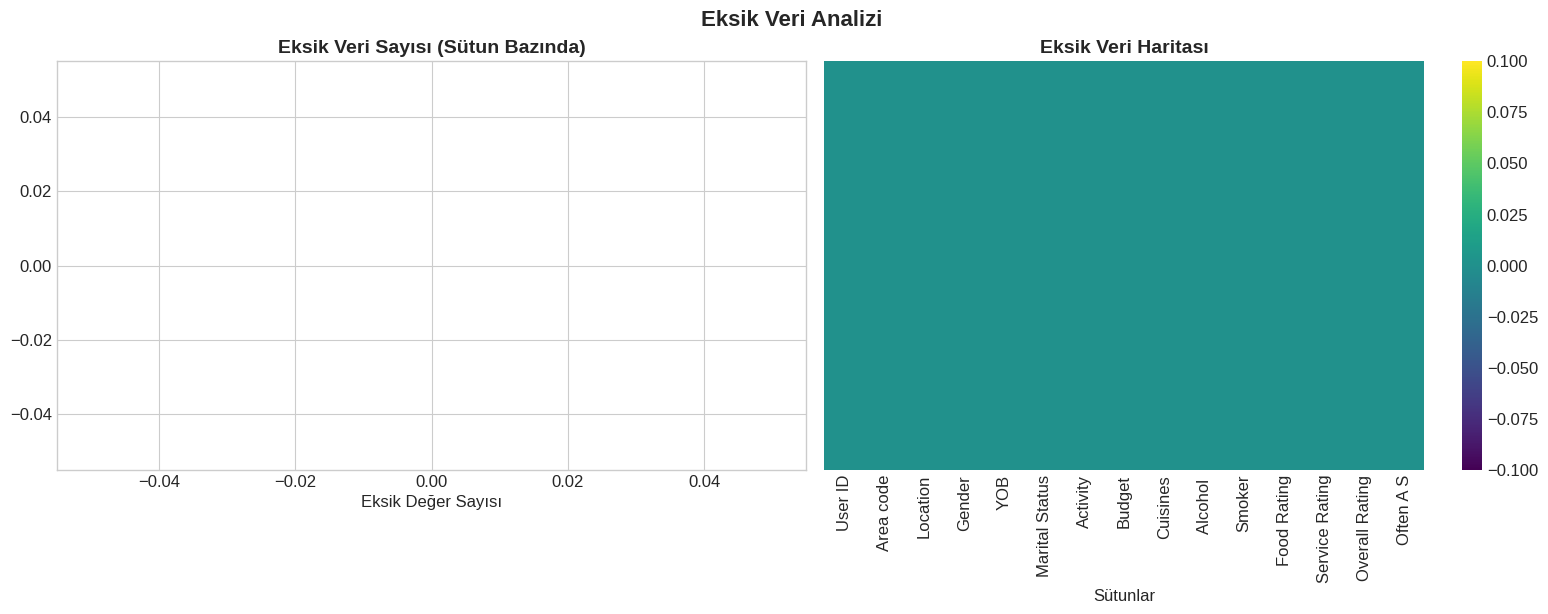

In [20]:
# Eksik veri görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
eksik_olan = df.isnull().sum()
eksik_olan = eksik_olan[eksik_olan > 0].sort_values(ascending=True)

colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 10 else '#3498db'
          for x in (eksik_olan / len(df) * 100)]

axes[0].barh(eksik_olan.index, eksik_olan.values, color=colors)
axes[0].set_title('Eksik Veri Sayısı (Sütun Bazında)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Eksik Değer Sayısı')
for i, (val, col) in enumerate(zip(eksik_olan.values, eksik_olan.index)):
    axes[0].text(val + 1, i, f'{val} ({val/len(df)*100:.1f}%)', va='center')

# Heatmap
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis',
            ax=axes[1])
axes[1].set_title('Eksik Veri Haritası', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sütunlar')

plt.tight_layout()
plt.suptitle('Eksik Veri Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.show()

###  eksik veri stratejileri



In [21]:
# 1. Veriyi bozmamak için kopyasını oluşturuyoruz
df_temiz = df.copy()

# 2. Sütun isimlerinin sağındaki/solundaki gizli boşlukları temizliyoruz (Mühendislik refleksi)
df_temiz.columns = df_temiz.columns.str.strip()

# 3. 'Overall Rating' sütununun medyanını hesaplıyoruz
rating_medyan = df_temiz['Overall Rating'].median()

# 4. Eksik (null) değerleri medyan ile dolduruyoruz
df_temiz['Overall Rating'].fillna(rating_medyan, inplace=True)

# 5. Temizleme sonrası veri setinde eksik değer kalıp kalmadığını kontrol ediyoruz
print("--- Eksik Değerlerin Güncel Durumu ---")
print(df_temiz.isnull().sum())

--- Eksik Değerlerin Güncel Durumu ---
User ID           0
Area code         0
Location          0
Gender            0
YOB               0
Marital Status    0
Activity          0
Budget            0
Cuisines          0
Alcohol           0
Smoker            0
Food Rating       0
Service Rating    0
Overall Rating    0
Often A S         0
dtype: int64


In [22]:
# 1. Sütun isimlerindeki gizli sağ-sol boşluklarını temizliyoruz
df_temiz.columns = df_temiz.columns.str.strip()

# 2. En çok tekrar eden mutfak türünü (Mod) buluyoruz (Cuisines olarak güncellendi)
en_cok_secilen_mutfak = df_temiz['Cuisines'].mode()[0]

# 3. Eksik (null) alanları bu en çok tekrar eden mutfak türü ile dolduruyoruz
df_temiz['Cuisines'].fillna(en_cok_secilen_mutfak, inplace=True)

# 4. Son durumu ve eksik değer tablosunu kontrol ediyoruz
print("--- Güncel Eksik Değer Durumu ---")
print(df_temiz.isnull().sum())

--- Güncel Eksik Değer Durumu ---
User ID           0
Area code         0
Location          0
Gender            0
YOB               0
Marital Status    0
Activity          0
Budget            0
Cuisines          0
Alcohol           0
Smoker            0
Food Rating       0
Service Rating    0
Overall Rating    0
Often A S         0
dtype: int64


In [23]:
# 1. Sütun isimlerini temizle
df_temiz.columns = df_temiz.columns.str.strip()

# 2. Veritabanını korumak için string'e çevirip ilk harfi alıyoruz (Titanic'teki deck mantığı)
df_temiz['location_kod'] = df_temiz['Location'].astype(str).str[0]

# 3. Eğer eksik/hatalı veri varsa 'Belirsiz' olarak dolduruyoruz
df_temiz['location_kod'].fillna('Belirsiz', inplace=True)

# 4. Hangi harften kaçar tane bölge kodu oluştuğunu ekrana yazdırıyoruz
print("--- Yeni Oluşturulan Konum Kodları Dağılımı ---")
print(df_temiz['location_kod'].value_counts())

--- Yeni Oluşturulan Konum Kodları Dağılımı ---
location_kod
C    56
U    48
S    46
R    28
M    22
Name: count, dtype: int64


## **Tek değişkenli analiz**

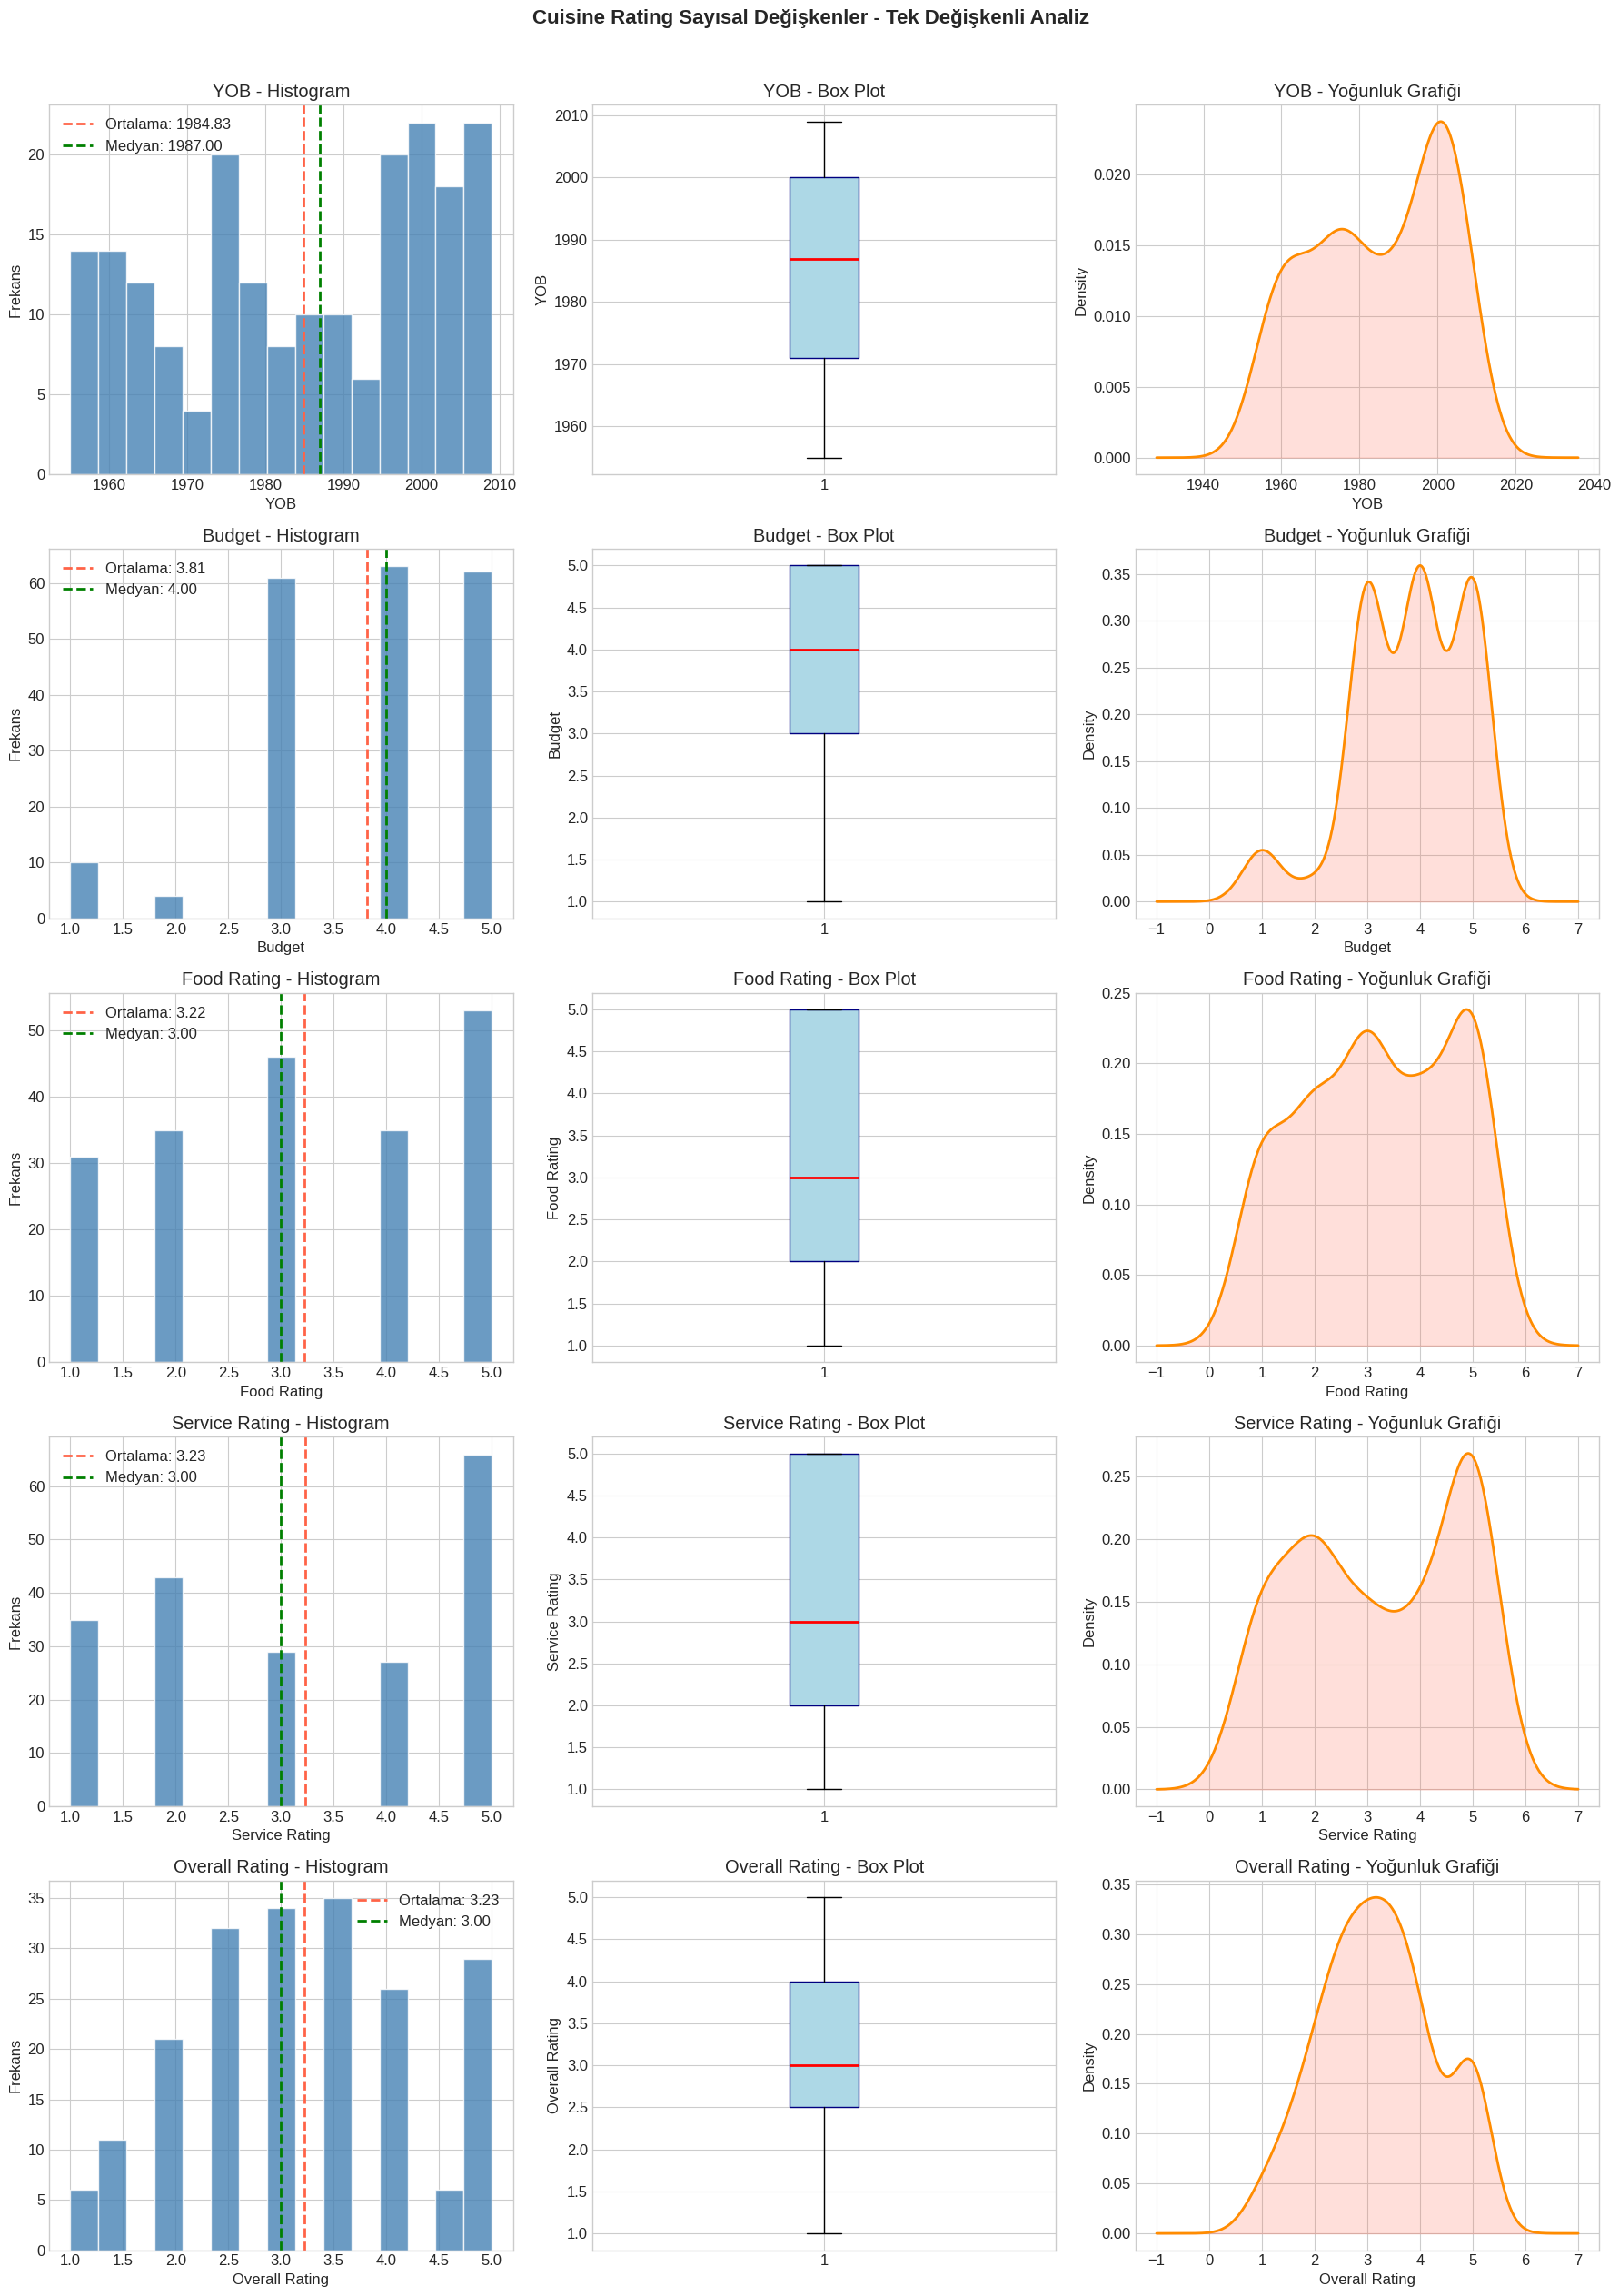

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Sütun isimlerindeki gizli boşlukları temizlediğimizden emin oluyoruz
df_temiz.columns = df_temiz.columns.str.strip()

# 2. Cuisine Rating veri setindeki anlamlı sayısal kolonları tanımlıyoruz
sayisal_kolonlar = ['YOB', 'Budget', 'Food Rating', 'Service Rating', 'Overall Rating']

# Grafikleri alt alta dizeceğimiz alt grafik (subplot) yapısını kuruyoruz
fig, axes = plt.subplots(len(sayisal_kolonlar), 3, figsize=(18, 5 * len(sayisal_kolonlar)))

for i, kolon in enumerate(sayisal_kolonlar):
    # Eksik verileri atlayarak temiz veriyi alıyoruz
    veri = df_temiz[kolon].dropna()

    # 1. Grafik: Histogram (Frekans Dağılımı)
    # Puanlama verileri kesikli (1, 2, 3, 4, 5) olduğu için bins değerini 15 yapmak daha net gösterir
    axes[i,0].hist(veri, bins=15, color="steelblue", edgecolor='white', alpha=0.8)
    axes[i,0].axvline(veri.mean(), color='tomato', linestyle='dashed', linewidth=2, label=f'Ortalama: {veri.mean():.2f}')
    axes[i,0].axvline(veri.median(), color='green', linestyle='dashed', linewidth=2, label=f'Medyan: {veri.median():.2f}')
    axes[i,0].set_title(f'{kolon} - Histogram')
    axes[i,0].legend()
    axes[i,0].set_xlabel(kolon)
    axes[i,0].set_ylabel('Frekans')

    # 2. Grafik: Box Plot (Aykırı Değer ve Çeyreklik Analizi)
    axes[i, 1].boxplot(veri, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', color='navy'),
                       medianprops=dict(color='red', linewidth=2))
    axes[i, 1].set_title(f'{kolon} - Box Plot')
    axes[i, 1].set_ylabel(kolon)

    # 3. Grafik: Yoğunluk Grafiği (KDE)
    veri.plot.kde(ax=axes[i,2], color='darkorange', linewidth=2)
    if len(axes[i,2].lines) > 0:
        axes[i,2].fill_between(axes[i,2].lines[0].get_xdata(),
                               axes[i,2].lines[0].get_ydata(),
                               color='tomato', alpha=0.2)
    axes[i,2].set_title(f'{kolon} - Yoğunluk Grafiği')
    axes[i,2].set_xlabel(kolon)

# Genel başlık ve yerleşim ayarları
plt.suptitle('Cuisine Rating Sayısal Değişkenler - Tek Değişkenli Analiz', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [25]:
# İstatistiksel özet tablo
print('Cuisine Rating Sayısal Değişkenler Detaylı İstatistikler:')
print('='*70)

# Önceki adımda belirlediğimiz veri setine özgü sayısal kolonları dönüyoruz
for kolon in sayisal_kolonlar:
    veri = df_temiz[kolon].dropna()

    print(f'\n * {kolon.upper()}')
    print(f'Ortalama        : {veri.mean():.2f}')
    print(f'Medyan          : {veri.median():.2f}')
    print(f'Standart Sapma  : {veri.std():.2f}')
    print(f'Minimum         : {veri.min():.2f}')
    print(f'Maksimum        : {veri.max():.2f}')
    print(f'Varyans         : {veri.var():.2f}')
    print(f'Skewness (Çarpıklık) : {veri.skew():.2f}')
    print(f'Kurtosis (Basıklık)  : {veri.kurtosis():.2f}')
    print(f'IQR (Çeyrekler Açıklığı): {veri.quantile(0.75) - veri.quantile(0.25):.2f}')
    print('='*70)

Cuisine Rating Sayısal Değişkenler Detaylı İstatistikler:

 * YOB
Ortalama        : 1984.83
Medyan          : 1987.00
Standart Sapma  : 16.81
Minimum         : 1955.00
Maksimum        : 2009.00
Varyans         : 282.55
Skewness (Çarpıklık) : -0.25
Kurtosis (Basıklık)  : -1.29
IQR (Çeyrekler Açıklığı): 29.00

 * BUDGET
Ortalama        : 3.81
Medyan          : 4.00
Standart Sapma  : 1.06
Minimum         : 1.00
Maksimum        : 5.00
Varyans         : 1.12
Skewness (Çarpıklık) : -0.76
Kurtosis (Basıklık)  : 0.36
IQR (Çeyrekler Açıklığı): 2.00

 * FOOD RATING
Ortalama        : 3.22
Medyan          : 3.00
Standart Sapma  : 1.41
Minimum         : 1.00
Maksimum        : 5.00
Varyans         : 1.99
Skewness (Çarpıklık) : -0.16
Kurtosis (Basıklık)  : -1.25
IQR (Çeyrekler Açıklığı): 3.00

 * SERVICE RATING
Ortalama        : 3.23
Medyan          : 3.00
Standart Sapma  : 1.53
Minimum         : 1.00
Maksimum        : 5.00
Varyans         : 2.33
Skewness (Çarpıklık) : -0.13
Kurtosis (Basıklık)  : -1

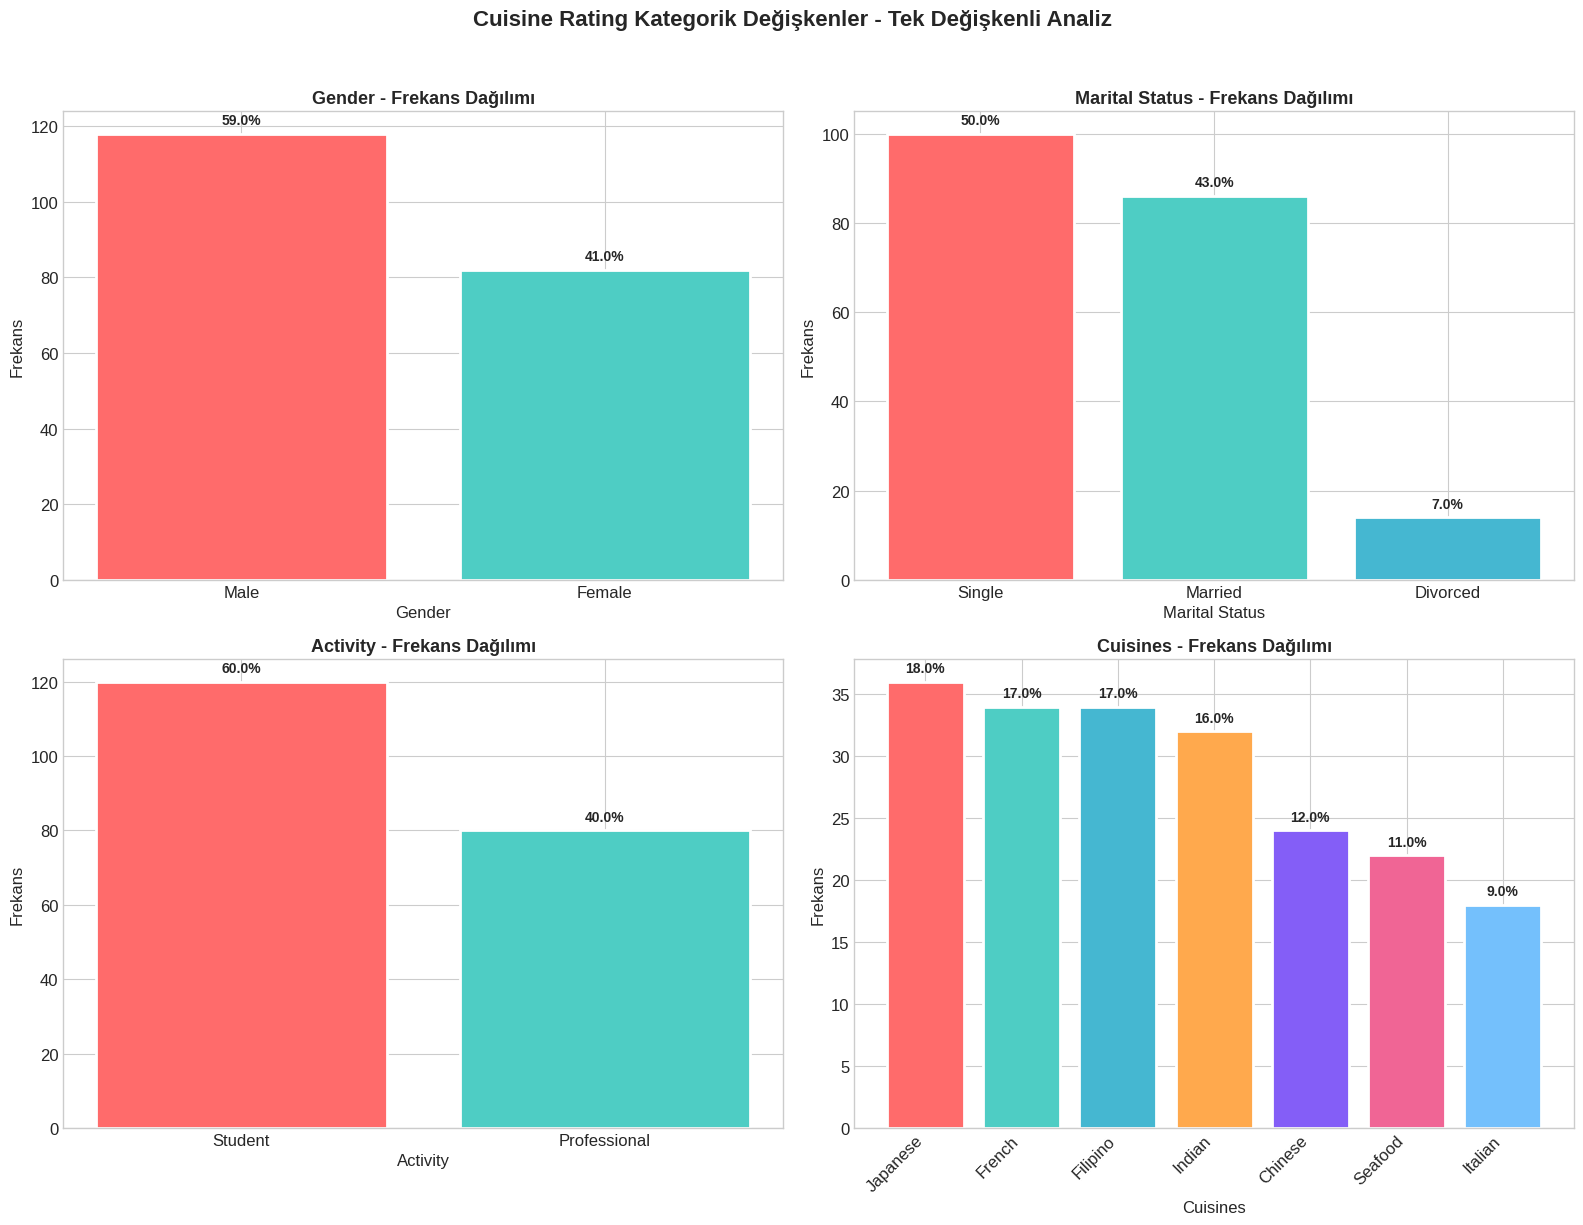

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Sütun isimlerindeki gizli boşlukları temizliyoruz
df_temiz.columns = df_temiz.columns.str.strip()

# 2. Cuisine Rating veri setindeki anlamlı 4 kategorik sütunu seçiyoruz
kategorik_kolonlar = ['Gender', 'Marital Status', 'Activity', 'Cuisines']

# 2x2 boyutunda bir grafik matrisi oluşturuyoruz
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Grafikler için şık bir renk paleti
renkler = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA94D', '#845EF7', '#F06595', '#74C0FC', '#63E6BE']

for i, kolon in enumerate(kategorik_kolonlar):
    # Her kategorinin frekansını (adetini) buluyoruz
    degerler = df_temiz[kolon].value_counts()

    # Yüzdelik oranlarını hesaplıyoruz
    yuzde = (degerler / len(df_temiz) * 100).round(2)

    # Bar (Sütun) grafiğini çizdiriyoruz
    bars = axes[i].bar(degerler.index.astype(str), degerler.values,
                       color=renkler[:len(degerler)], edgecolor='white', linewidth=2)

    # Grafik başlık ve eksen ayarları
    axes[i].set_title(f'{kolon} - Frekans Dağılımı', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(kolon)
    axes[i].set_ylabel('Frekans')

    # Mutfak türleri (Cuisines) çok fazla olursa yazılar birbirine girmesin diye X ekseni yazılarını eğiyoruz
    if kolon == 'Cuisines':
        axes[i].set_xticklabels(degerler.index.astype(str), rotation=45, ha='right')

    # Her sütunun üzerine yüzde değerini yazdırıyoruz
    # Toplam veri sayısına göre dinamik bir boşluk (offset) bırakıyoruz
    offset = max(degerler.values) * 0.015
    for bar, pct in zip(bars, yuzde.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + offset,
                     f'{pct}%',
                     ha='center',
                     va='bottom',
                     fontsize=10,
                     fontweight='bold')

# Genel başlık ayarları
plt.suptitle('Cuisine Rating Kategorik Değişkenler - Tek Değişkenli Analiz', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Çift değişkenli Analiz

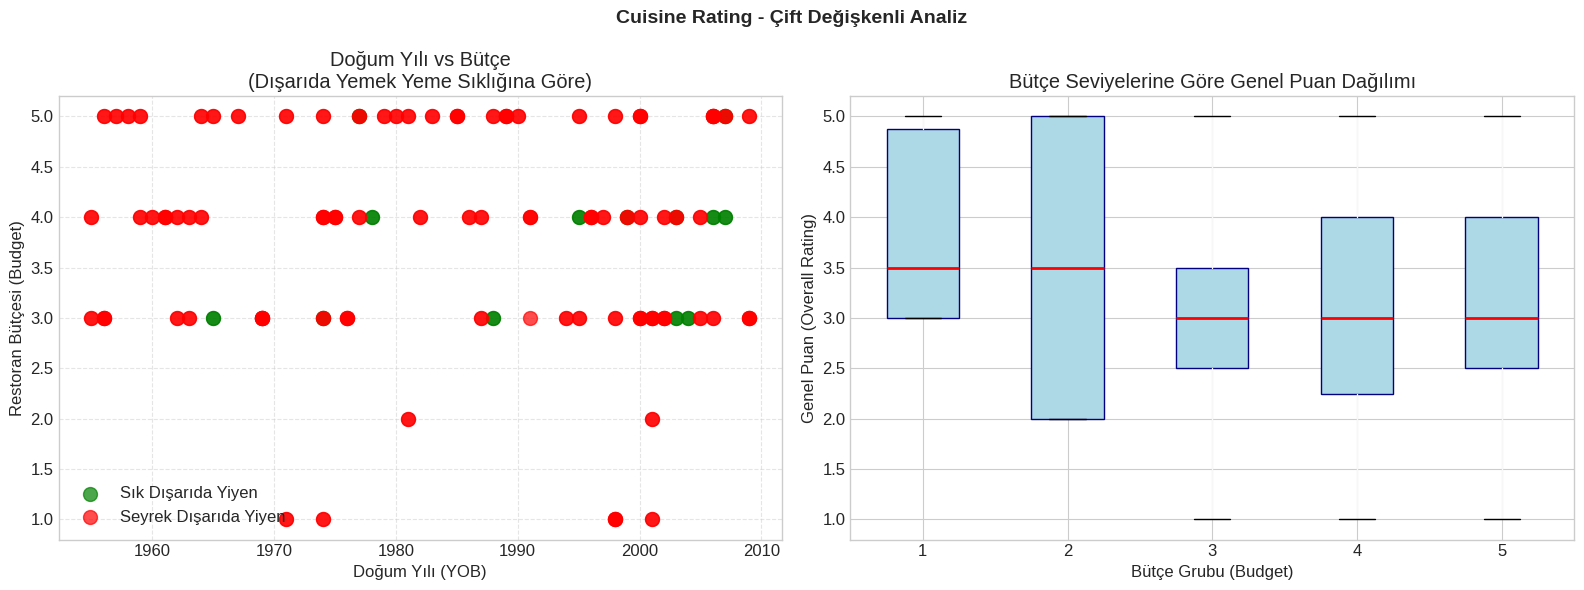

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Sütun isimlerindeki gizli boşlukları temizliyoruz
df_temiz.columns = df_temiz.columns.str.strip()

# 2. Grafik alanını oluşturuyoruz (1 satır, 2 sütun)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 1. GRAFİK: Scatter Plot (Doğum Yılı vs Bütçe - Dışarıda Yemek Yeme Sıklığına Göre) ---
# Dışarıda sık yiyenler (Yes) ve yemeyenler (No) olarak veriyi ikiye bölüyoruz
sikyiyen = df_temiz[df_temiz['Often A S'] == 'Yes']
azyiyen = df_temiz[df_temiz['Often A S'] == 'No']

axes[0].scatter(sikyiyen['YOB'], sikyiyen['Budget'], color='green', alpha=0.7, label='Sık Dışarıda Yiyen', s=100)
axes[0].scatter(azyiyen['YOB'], azyiyen['Budget'], color='red', alpha=0.7, label='Seyrek Dışarıda Yiyen', s=100)

axes[0].set_xlabel('Doğum Yılı (YOB)')
axes[0].set_ylabel('Restoran Bütçesi (Budget)')
axes[0].set_title('Doğum Yılı vs Bütçe\n(Dışarıda Yemek Yeme Sıklığına Göre)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- 2. GRAFİK: Box Plot (Bütçe Grubuna Göre Genel Puan Dağılımı) ---
# Titanic'teki pclass vs fare mantığıyla: Bütçe seviyelerine göre Overall Rating dağılımını inceliyoruz
df_temiz.boxplot(column='Overall Rating', by='Budget', ax=axes[1],
                 patch_artist=True,
                 boxprops=dict(facecolor='lightblue', color='navy'),
                 medianprops=dict(color='red', linewidth=2))

axes[1].set_xlabel('Bütçe Grubu (Budget)')
axes[1].set_ylabel('Genel Puan (Overall Rating)')
axes[1].set_title('Bütçe Seviyelerine Göre Genel Puan Dağılımı')

# Pandas'ın otomatik oluşturduğu alt başlığı temizleyerek görüntüyü netleştiriyoruz
plt.suptitle('Cuisine Rating - Çift Değişkenli Analiz', fontsize=14, fontweight='bold')
if axes[1].get_figure():
    axes[1].get_figure().suptitle('Cuisine Rating - Çift Değişkenli Analiz', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [28]:
# 1. Sütun isimlerindeki gizli boşlukları temizliyoruz
df_temiz.columns = df_temiz.columns.str.strip()

# En düşük bütçeli (Budget = 3) müşterileri filtreliyoruz
dusuk_butceli = df_temiz[df_temiz['Budget'] == 3]

toplam_dusuk_butceli = len(dusuk_butceli)

# Bu düşük bütçelilerden dışarıda SIK yemek yiyenlerin sayısı
hem_dusuk_hem_sik_yiyen = (dusuk_butceli['Often A S'] == 'Yes').sum()

# Toplamdan çıkardığımızda dışarıda SEYREK yemek yiyenleri buluyoruz
seyrek_yiyen_dusuk_butceli = toplam_dusuk_butceli - hem_dusuk_hem_sik_yiyen

# Sonuçları ekrana basıyoruz
print(toplam_dusuk_butceli)
print(hem_dusuk_hem_sik_yiyen)
print(seyrek_yiyen_dusuk_butceli)

61
10
51


In [29]:
# Sütun isimlerini temizliyoruz
df_temiz.columns = df_temiz.columns.str.strip()

# En düşük bütçeli (Budget == 3) olanların dışarıda yeme sıklığı dağılımı
df_temiz[df_temiz["Budget"] == 3]["Often A S"].value_counts()

,count
Often A S,
No,51
Yes,10


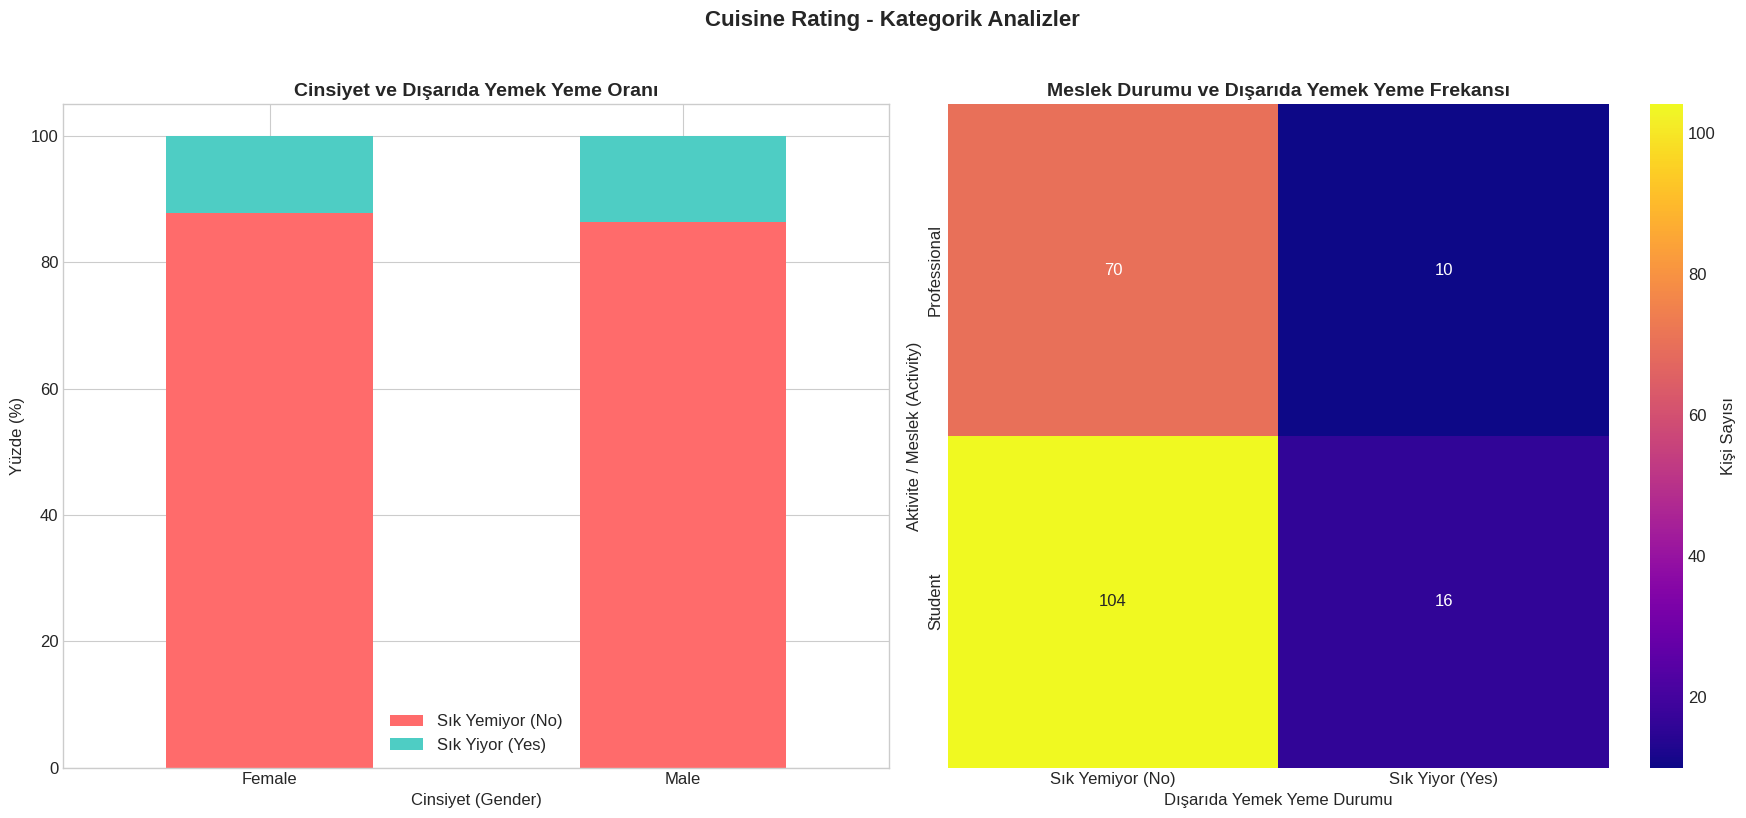

In [30]:
# Grafik alanını oluşturuyoruz (1 satır, 2 sütun)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- 1. GRAFİK: Cinsiyet ve Dışarıda Yemek Yeme Oranı (Stacked Bar) ---
# Çapraz tablo oluşturup satır bazında yüzdeliyoruz (normalize='index')
ct_pct = pd.crosstab(df_temiz['Gender'], df_temiz['Often A S'], normalize='index') * 100

# Yığılmış bar grafiğini çizdiriyoruz
ct_pct.plot(kind='bar', stacked=True, color=['#FF6B6B', '#4ECDC4'], ax=axes[0])

axes[0].set_title('Cinsiyet ve Dışarıda Yemek Yeme Oranı', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cinsiyet (Gender)')
axes[0].set_ylabel('Yüzde (%)')
axes[0].legend(['Sık Yemiyor (No)', 'Sık Yiyor (Yes)'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# --- 2. GRAFİK: Aktivite/Meslek Durumu ve Dışarıda Yemek Yeme (Heatmap) ---
# Aktivite durumu ile dışarıda yeme sıklığı arasındaki kişi sayılarını buluyoruz
ct2 = pd.crosstab(df_temiz['Activity'], df_temiz['Often A S'])

# Tablo sütun isimlerini grafikte güzel görünmesi için netleştiriyoruz
ct2.columns = ['Sık Yemiyor (No)', 'Sık Yiyor (Yes)']

# Isı haritasını (Heatmap) çizdiriyoruz
sns.heatmap(ct2, annot=True, fmt='d', cmap='plasma', ax=axes[1], cbar_kws={'label': 'Kişi Sayısı'})

axes[1].set_title('Meslek Durumu ve Dışarıda Yemek Yeme Frekansı', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Dışarıda Yemek Yeme Durumu')
axes[1].set_ylabel('Aktivite / Meslek (Activity)')

# Genel başlık ayarları
plt.suptitle('Cuisine Rating - Kategorik Analizler', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

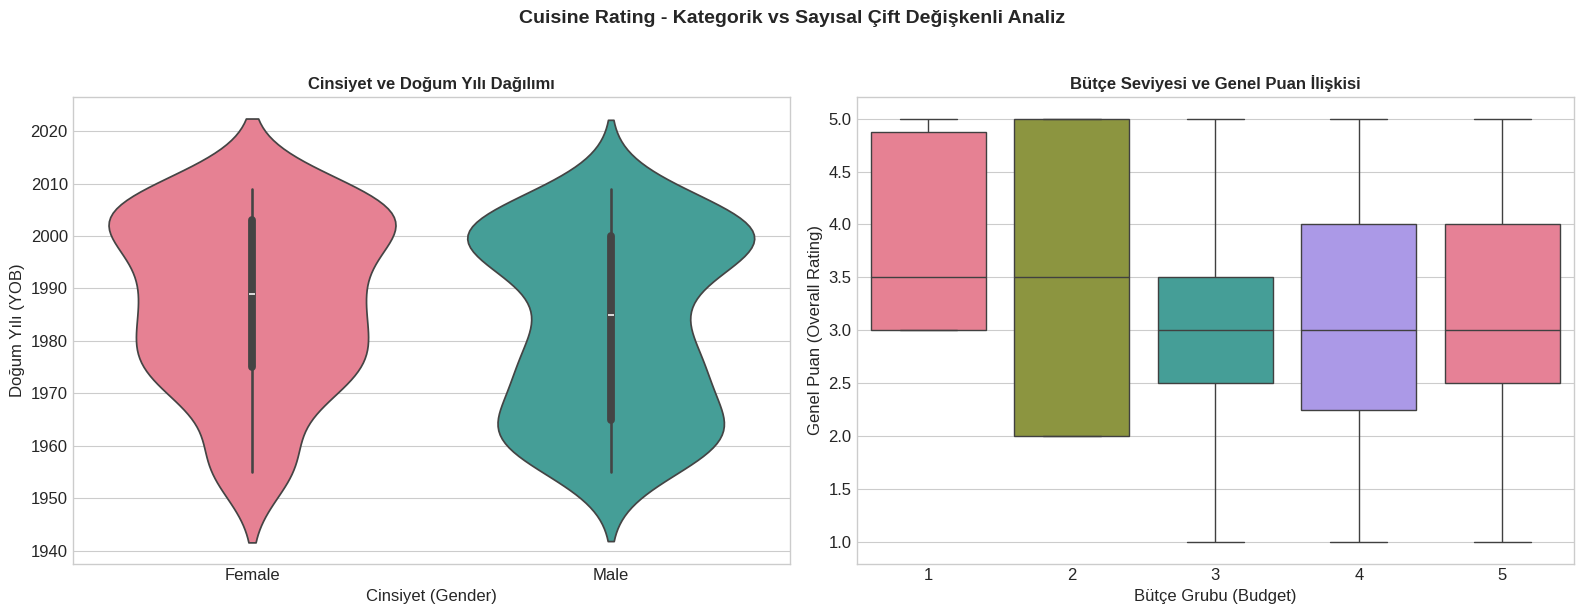

In [33]:
 #Grafik alanını oluşturuyoruz (1 satır, 2 sütun olarak optimize edildi)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 1. GRAFİK: Cinsiyete Göre Doğum Yılı Dağılımı (Violin Plot) ---
# Titanic'teki sex vs age yerine Gender vs YOB kullanıyoruz
sns.violinplot(data=df_temiz, x='Gender', y='YOB', ax=axes[0], palette='husl', hue='Gender', legend=False)
axes[0].set_title('Cinsiyet ve Doğum Yılı Dağılımı', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cinsiyet (Gender)')
axes[0].set_ylabel('Doğum Yılı (YOB)')

# --- 2. GRAFİK: Bütçe Seviyesine Göre Genel Puan Dağılımı (Box Plot) ---
# Titanic'teki pclass vs age yerine Budget vs Overall Rating kullanıyoruz
sns.boxplot(data=df_temiz, x='Budget', y='Overall Rating', ax=axes[1], palette='husl', hue='Budget', legend=False)
axes[1].set_title('Bütçe Seviyesi ve Genel Puan İlişkisi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Bütçe Grubu (Budget)')
axes[1].set_ylabel('Genel Puan (Overall Rating)')

# Genel başlık ve yerleşim ayarları
plt.suptitle('Cuisine Rating - Kategorik vs Sayısal Çift Değişkenli Analiz', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [34]:
df_new= pd.read_csv('/content/Cuisine_rating.csv')

In [35]:
df_new.head()

,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
0,1,153,"Upper East Side,NY",Female,2006,Single,Professional,3,Japanese,Never,Never,5,4,4.50,No
1,2,123,"St. George,NY",Female,1991,Married,Student,3,Indian,Never,Socially,1,1,1.00,No
2,3,122,"Upper West Side,NY",Male,1977,Single,Student,5,Seafood,Often,Often,5,5,5.00,Yes
3,4,153,"Upper East Side,NY",Female,1956,Married,Professional,5,Japanese,Never,Socially,3,1,2.00,No
4,5,129,"Central Park,NY",Male,1997,Single,Student,4,Filipino,Socially,Never,2,4,3.00,No


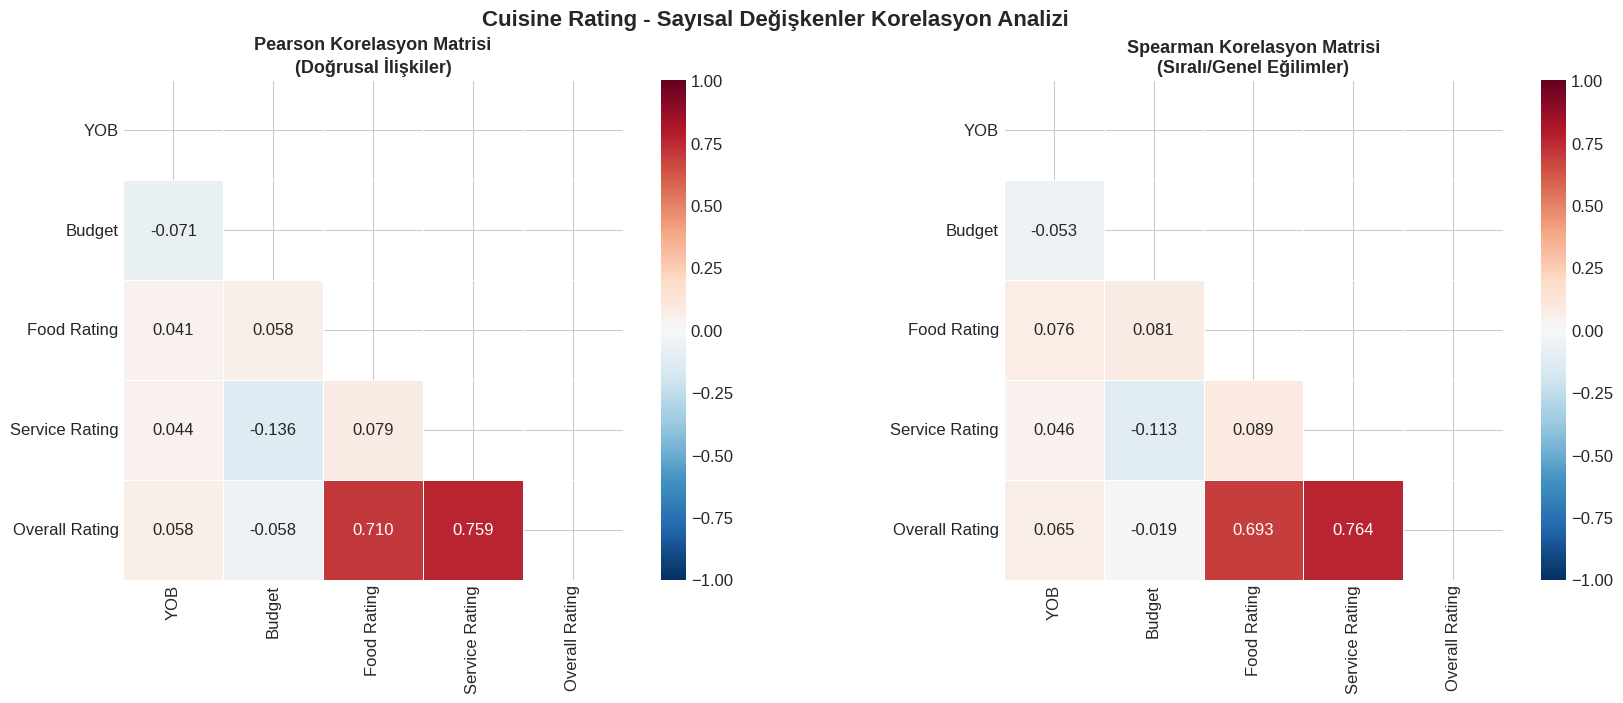

In [36]:

sayisal_kolonlar = ['YOB', 'Budget', 'Food Rating', 'Service Rating', 'Overall Rating']
sayisal_df = df_temiz[sayisal_kolonlar]

# Grafik alanını oluşturuyoruz (1 satır, 2 sütun)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Korelasyon matrisinin simetrik (ayna) kopyasını gizlemek için üst üçgen maskesi oluşturuyoruz
# pearson_corr tablosuyla aynı boyutta sıfırlardan oluşan bir matris üretip üst kısmı True yapar
mask = np.triu(np.ones_like(sayisal_df.corr(method='pearson'), dtype=bool))

# --- 1. GRAFİK: Pearson Korelasyon Matrisi ---
pearson_corr = sayisal_df.corr(method='pearson')
sns.heatmap(pearson_corr,
            mask=mask,
            annot=True,
            fmt='.3f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            ax=axes[0],
            vmin=-1, vmax=1)
axes[0].set_title('Pearson Korelasyon Matrisi\n(Doğrusal İlişkiler)', fontsize=13, fontweight='bold')

# --- 2. GRAFİK: Spearman Korelasyon Matrisi ---
spearman_corr = sayisal_df.corr(method='spearman')
sns.heatmap(spearman_corr,
            mask=mask,
            annot=True,
            fmt='.3f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            ax=axes[1],
            vmin=-1, vmax=1)
axes[1].set_title('Spearman Korelasyon Matrisi\n(Sıralı/Genel Eğilimler)', fontsize=13, fontweight='bold')

# Genel başlık ayarları
plt.suptitle('Cuisine Rating - Sayısal Değişkenler Korelasyon Analizi', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

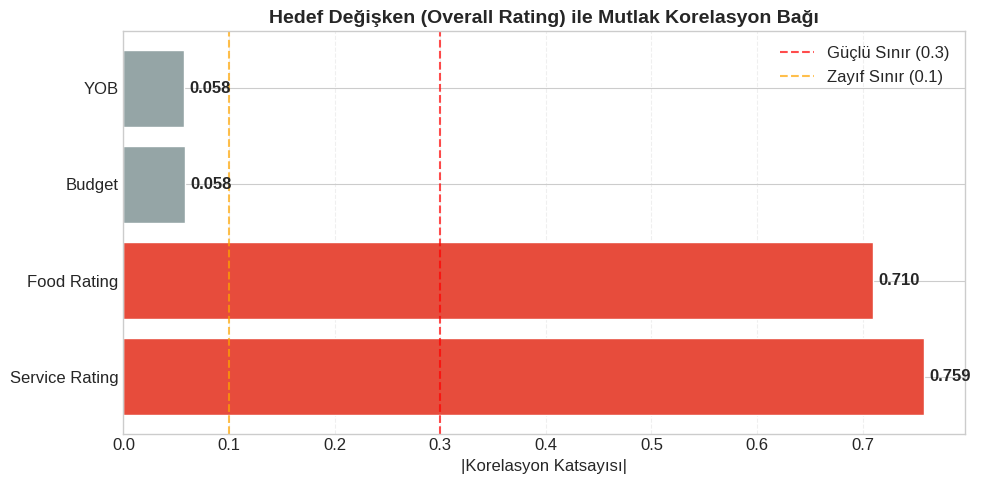


💡 Yorum:
   Müşteri memnuniyetini (Overall Rating) etkileyen EN GÜÇLÜ faktör: Service Rating (0.759)
   Müşteri memnuniyetini etkileyen EN ZAYIF faktör : YOB (0.058)


In [37]:
# 2. Pearson korelasyon matrisini hesaplıyoruz (Bir önceki adımda yaptığımız gibi)
sayisal_kolonlar = ['YOB', 'Budget', 'Food Rating', 'Service Rating', 'Overall Rating']
pearson_corr = df_temiz[sayisal_kolonlar].corr(method='pearson')

# 3. Hedef değişkenimizi 'Overall Rating' olarak seçiyoruz
# Kendisiyle olan 1.0'lık korelasyonu düşürüp (drop), mutlak değerini (abs) alıp sıralıyoruz
hedef_corr = pearson_corr['Overall Rating'].drop('Overall Rating').abs().sort_values(ascending=False)

# Grafik alanını oluşturuyoruz
fig, ax = plt.subplots(figsize=(10, 5))

# Korelasyon derecesine göre dinamik renk paleti atıyoruz (Titanic mantığıyla birebir aynı)
renkler = ['#e74c3c' if c > 0.3 else '#f39c12' if c > 0.1 else '#95a5a6'
           for c in hedef_corr.values]

# Yatay bar grafiğini çizdiriyoruz
bars = ax.barh(hedef_corr.index, hedef_corr.values, color=renkler, edgecolor='white')
ax.set_title('Hedef Değişken (Overall Rating) ile Mutlak Korelasyon Bağı', fontsize=14, fontweight='bold')
ax.set_xlabel('|Korelasyon Katsayısı|')

# Sınır çizgilerini çekiyoruz
ax.axvline(0.3, color='red', linestyle='--', alpha=0.7, label='Güçlü Sınır (0.3)')
ax.axvline(0.1, color='orange', linestyle='--', alpha=0.7, label='Zayıf Sınır (0.1)')
ax.legend()

# Barların hemen sağ ucuna tam korelasyon değerlerini yazdırıyoruz
for bar, val in zip(bars, hedef_corr.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold')

plt.tight_layout()
# Eğer grafik çizgilerinin arkada kalmasını istersen grid ekleyebilirsin
ax.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

# --- Dinamik İstatistiksel Yorum Bölümü ---
print('\n💡 Yorum:')
print(f'   Müşteri memnuniyetini (Overall Rating) etkileyen EN GÜÇLÜ faktör: {hedef_corr.index[0]} ({hedef_corr.values[0]:.3f})')
print(f'   Müşteri memnuniyetini etkileyen EN ZAYIF faktör : {hedef_corr.index[-1]} ({hedef_corr.values[-1]:.3f})')

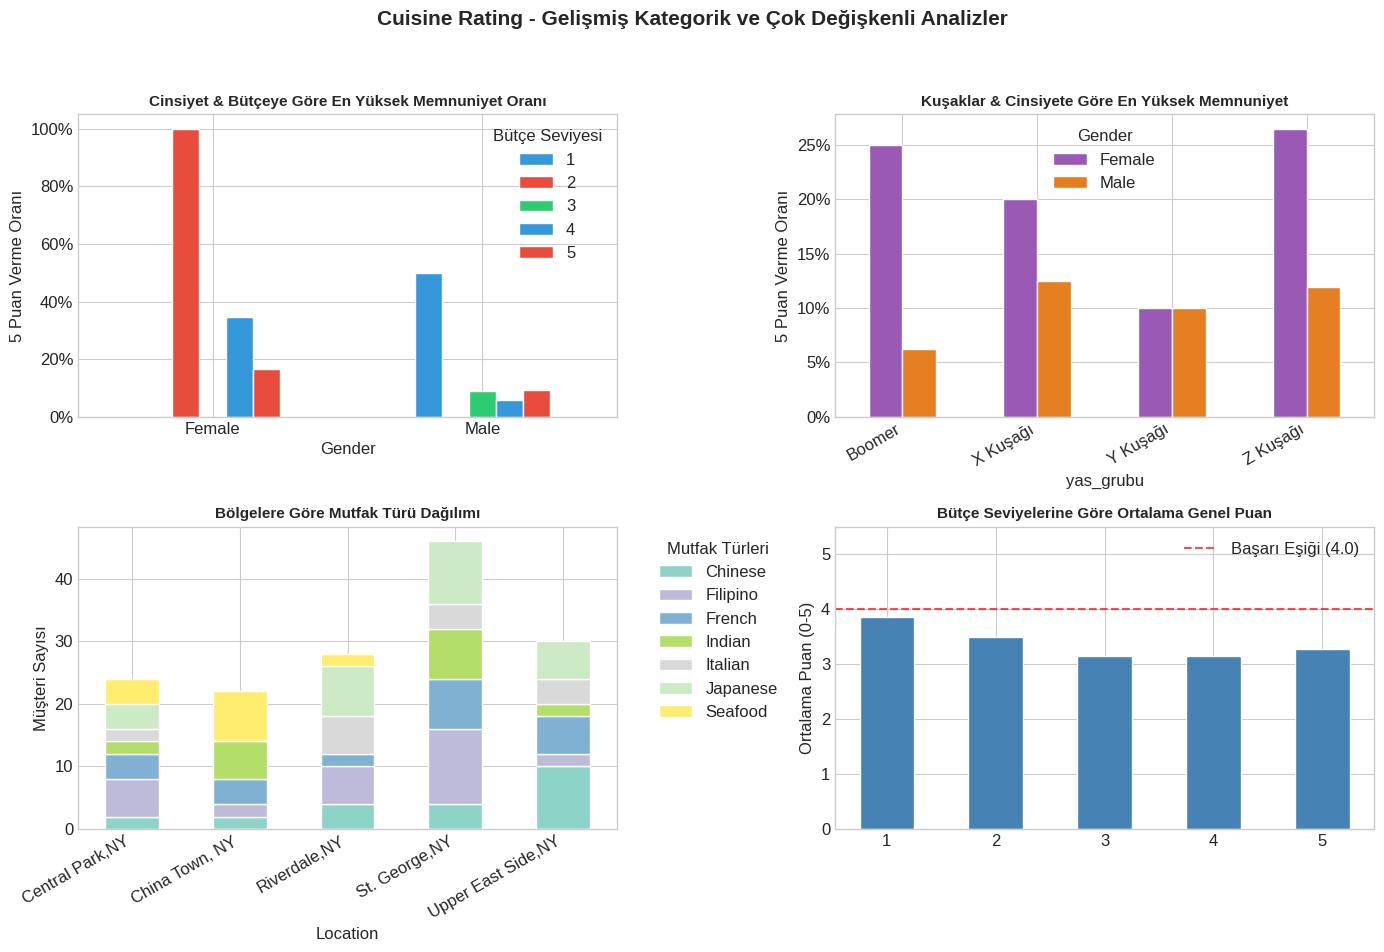

In [41]:

import pandas as pd
import matplotlib.pyplot as plt

# Veriyi yükle
df = pd.read_csv('Cuisine_rating.csv')

# 1. Mutlu Müşteri sütununu oluştur (Overall Rating 5 ise 1, değilse 0)
df['mutlu_musteri'] = (df['Overall Rating'] == 5).astype(int)

# Görselleştirme için figür ayarları
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- 1. GRAFİK ---
pivot1 = df.groupby(['Gender', 'Budget'])['mutlu_musteri'].mean().unstack()
pivot1.plot(kind='bar', ax=axes[0, 0], color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='white')
axes[0, 0].set_title('Cinsiyet & Bütçeye Göre En Yüksek Memnuniyet Oranı', fontweight='bold', fontsize=11)
axes[0, 0].set_ylabel('5 Puan Verme Oranı')
axes[0, 0].legend(title='Bütçe Seviyesi')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# --- 2. GRAFİK ---
df['yas_grubu'] = pd.cut(df['YOB'],
                         bins=[0, 1965, 1980, 1995, 2010],
                         labels=['Boomer', 'X Kuşağı', 'Y Kuşağı', 'Z Kuşağı'])

pivot2 = df.groupby(['yas_grubu', 'Gender'])['mutlu_musteri'].mean().unstack()
pivot2.plot(kind='bar', ax=axes[0, 1], color=['#9b59b6', '#e67e22'], edgecolor='white')
axes[0, 1].set_title('Kuşaklar & Cinsiyete Göre En Yüksek Memnuniyet', fontweight='bold', fontsize=11)
axes[0, 1].set_ylabel('5 Puan Verme Oranı')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=30, ha='right')
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# --- 3. GRAFİK ---
populer_konumlar = df['Location'].value_counts().index[:5]
df_sub = df[df['Location'].isin(populer_konumlar)]

pivot3 = df_sub.groupby(['Location', 'Cuisines']).size().unstack(fill_value=0)
pivot3.plot(kind='bar', stacked=True, ax=axes[1, 0], edgecolor='white', cmap='Set3')
axes[1, 0].set_title('Bölgelere Göre Mutfak Türü Dağılımı', fontweight='bold', fontsize=11)
axes[1, 0].set_ylabel('Müşteri Sayısı')
axes[1, 0].legend(title='Mutfak Türleri', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=30, ha='right')

# --- 4. GRAFİK ---
butce_puan = df.groupby('Budget')['Overall Rating'].mean()
axes[1, 1].bar(butce_puan.index.astype(str), butce_puan.values, color='steelblue', edgecolor='white', width=0.5)
axes[1, 1].set_title('Bütçe Seviyelerine Göre Ortalama Genel Puan', fontweight='bold', fontsize=11)
axes[1, 1].set_ylabel('Ortalama Puan (0-5)')
axes[1, 1].axhline(4.0, color='red', linestyle='--', alpha=0.7, label='Başarı Eşiği (4.0)')
axes[1, 1].set_ylim(0, 5.5)
axes[1, 1].legend()

plt.suptitle('Cuisine Rating - Gelişmiş Kategorik ve Çok Değişkenli Analizler', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [40]:

# 1. Tekrarlanabilir rastgele veriler için seed sabitliyoruz
np.random.seed(42)

# 2. 3 yıllık günlük tarih dizisi oluşturuyoruz
tarihler = pd.date_range(start='2022-01-01', end='2024-12-31', freq='D')
n = len(tarihler)

# 3. Zaman serisi bileşenlerini oluşturuyoruz (Zaman Serisi Dekompozisyonu mantığı)
trend = np.linspace(100, 200, n)  # Zamanla yukarı doğru giden kalıcı eğilim
mevsimsellik = 30 * np.sin(2 * np.pi * np.arange(n) / 365)  # Yıllık periyotlar (Yaz/Kış döngüsü)
haftalik = 10 * np.sin(2 * np.pi * np.arange(n) / 7)  # Haftalık periyotlar (Hafta sonu yoğunluğu gibi)
gurultu = np.random.normal(0, 15, n)  # Öngörülemeyen rastgele dış etkenler

# Bileşenleri topluyoruz (Eklemeli - Additive Model)
degerler = trend + mevsimsellik + haftalik + gurultu

# 4. DataFrame yapısına dönüştürüyoruz (Negatif satış olamayacağı için taban sınır 0 yapılıyor)
ts_df = pd.DataFrame({
    'satis': np.maximum(degerler, 0).round(2)
}, index=tarihler)

# İndeks ismini netleştiriyoruz
ts_df.index.name = 'tarih'

print('📅 Sentetik Zaman Serisi Veri Seti Başarıyla Oluşturuldu!')
print(f'Toplam Gün Sayısı: {len(ts_df)}')
print('-' * 40)
print(ts_df.head(10))  # İlk 10 günü kontrol ediyoruz
print('-' * 40)



📅 Sentetik Zaman Serisi Veri Seti Başarıyla Oluşturuldu!
Toplam Gün Sayısı: 1096
----------------------------------------
            satis
tarih            
2022-01-01 107.45
2022-01-02 106.35
2022-01-03 120.68
2022-01-04 129.01
2022-01-05  94.58
2022-01-06  89.77
2022-01-07 119.51
2022-01-08 115.76
2022-01-09 105.63
2022-01-10 123.34
----------------------------------------
